# Oil-refinery simulation foundation with NeqSim

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/neqsim_oil_refinery_simulation_foundation.ipynb)

**From crude assay to front-end separation, energy, emissions, and refinery margin**

This notebook builds a transparent refinery front-end model around a synthetic North Sea
crude. NeqSim models the thermodynamic state, preheat, preflash drum, atmospheric furnace,
and flash-zone separation. Python closes component, mass, energy, cut-recovery, emissions,
and economic ledgers. The result connects physical refinery behaviour to the separate
European crude-oil sales notebook.

This is an equilibrium screening model, not a design model for a real refinery or a
substitute for a calibrated crude assay, rigorous distillation, reaction kinetics,
equipment rating, HAZOP, operating procedures, or licensed engineering standards.

## Learning outcomes

1. Turn a synthetic TBP assay into NeqSim pseudo-components and boiling-range cuts.
2. Assemble a reproducible `ProcessSystem` for preheat, preflash, furnace, and flash zone.
3. Reconcile every component, total mass, heater duty, and broad-cut recovery.
4. Explore temperature, heat recovery, fuel, emissions, and refinery-margin sensitivities.
5. Distinguish what NeqSim can screen from what requires a full refinery simulator.

## 1. Model boundary and decision layers

| Layer | This notebook | Production extension |
|---|---|---|
| Crude receipt | synthetic dry crude assay | reconciled laboratory assay, salt, BS&W, metals |
| CDU front end | preheat, preflash, furnace, equilibrium flash | rigorous pumparounds and side strippers |
| Products | broad boiling-range recovery | ASTM curves, qualities, blending, rundown tanks |
| Conversion | value placeholders only | hydroprocessing, FCC, hydrocracker, reformer, coker kinetics |
| Utilities | purchased heat, fuel and direct CO2 screen | steam/power network, exchanger design, constraints |
| Economics | gross product worth and variable-margin screen | LP planning, inventory, maintenance, taxes and risk |

The thermodynamic layer and commercial layer share mass and energy bases, but they remain
separate ledgers. A market price is not a thermodynamic property; a flash yield is not a
contractual product yield.

## 2. Reproducible NeqSim Java `master` runtime

The next cells build current NeqSim `master` in Colab and verify the commit, JAR hash, and
class source. Local validation used the same source-first class-loading contract.

In [1]:
import hashlib
import os
import platform
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
os.environ.setdefault("NEQSIM_JVM_AUTOSTART", "false")

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "jpype1==1.7.1",
            "numpy",
            "pandas",
            "matplotlib",
            "scipy",
            "networkx",
        ],
        check=True,
    )
    source_root = Path("neqsim-java-master")
    if not source_root.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                "https://github.com/equinor/neqsim.git",
                str(source_root),
            ],
            check=True,
        )
    subprocess.run(
        ["./mvnw", "-q", "-DskipTests", "package"],
        cwd=source_root,
        check=True,
    )
    candidates = sorted((source_root / "target").glob("neqsim-*.jar"))
    candidates = [path for path in candidates if "original" not in path.name]
    if not candidates:
        raise FileNotFoundError("The NeqSim source build produced no runtime JAR.")
    NEQSIM_JAR = max(candidates, key=lambda path: path.stat().st_size).resolve()
else:
    source_root = Path(os.environ.get("NEQSIM_SOURCE_ROOT", "neqsim-java-master"))
    source_jar = os.environ.get("NEQSIM_SOURCE_JAR", "")
    if not source_jar:
        raise RuntimeError("Set NEQSIM_SOURCE_JAR for local clean validation.")
    NEQSIM_JAR = Path(source_jar).resolve()

NEQSIM_COMMIT = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    cwd=source_root,
    text=True,
).strip()
NEQSIM_JAR_SHA256 = hashlib.sha256(NEQSIM_JAR.read_bytes()).hexdigest()
dependency_text = os.environ.get("NEQSIM_DEPENDENCY_JAR", "")
NEQSIM_DEPENDENCY_JARS = [
    Path(item).resolve()
    for item in dependency_text.split(os.pathsep)
    if item
]

print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_COMMIT}")
print(f"NeqSim source-built JAR: {NEQSIM_JAR}")
print(f"NeqSim JAR SHA-256: {NEQSIM_JAR_SHA256}")
print(f"Python: {platform.python_version()}")

NeqSim source ref: master
NeqSim source commit: 7ae08253b45180045a99a700314f23c9a7001b3c
NeqSim source-built JAR: /workspace/scratch/677f236dc7cc/gas-market-work/neqsim-java-master/target/neqsim-current-master.jar
NeqSim JAR SHA-256: d1bdf734644537f2304d17e2e354008c48f189858a9055cc6c5aee11034344ba
Python: 3.12.13


In [2]:
import json
import math
from importlib import metadata

import jpype
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import scipy
from IPython.display import display
from jpype import JClass
from matplotlib.patches import Patch
from scipy.optimize import linprog

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 30)

class_path = [str(NEQSIM_JAR)]
class_path.extend(str(path) for path in NEQSIM_DEPENDENCY_JARS)
if not jpype.isJVMStarted():
    # Direct JVM startup is the validated equivalent of jpype.addClassPath.
    jpype.startJVM(classpath=class_path)

SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
StandardISO6976 = JClass(
    "neqsim.standards.gasquality.Standard_ISO6976_2016"
)
Stream = JClass("neqsim.process.equipment.stream.Stream")
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")
class_source = str(
    SystemSrkEos.class_.getProtectionDomain().getCodeSource().getLocation()
)
print(f"Loaded NeqSim class code source: {class_source}")
assert str(NEQSIM_JAR) in class_source

Loaded NeqSim class code source: file:/workspace/scratch/677f236dc7cc/gas-market-work/neqsim-java-master/target/neqsim-current-master.jar


In [3]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from jpype import JClass
from scipy.optimize import linprog

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 30)

class_path = [str(NEQSIM_JAR)]
class_path.extend(str(path) for path in NEQSIM_DEPENDENCY_JARS)
if not jpype.isJVMStarted():
    # Direct JVM startup is the validated equivalent of jpype.addClassPath.
    jpype.startJVM(classpath=class_path)

SystemPrEos = JClass("neqsim.thermo.system.SystemPrEos")
Stream = JClass("neqsim.process.equipment.stream.Stream")
Heater = JClass("neqsim.process.equipment.heatexchanger.Heater")
Separator = JClass("neqsim.process.equipment.separator.Separator")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")
ThermodynamicOperations = JClass(
    "neqsim.thermodynamicoperations.ThermodynamicOperations"
)

refinery_class_source = str(
    Heater.class_.getProtectionDomain().getCodeSource().getLocation()
)
print(f"Loaded refinery equipment class code source: {refinery_class_source}")
assert str(NEQSIM_JAR) in refinery_class_source

Loaded refinery equipment class code source: file:/workspace/scratch/677f236dc7cc/gas-market-work/neqsim-java-master/target/neqsim-current-master.jar


## 3. Python tools around the refinery model

| Need | Python route | Role |
|---|---|---|
| Thermodynamics and process | NeqSim through JPype | EOS, flashes, streams, equipment, duties |
| Assay and ledgers | pandas, NumPy | cut mapping, balances, scenario tables |
| Planning optimisation | SciPy `linprog`, Pyomo or CVXPY | crude slate and unit constraints |
| Parameter estimation | SciPy, lmfit | reconcile assay and operating data |
| Time series and historian | pandas, Polars, SQL clients | plant snapshots and backtesting |
| Flowsheets and reporting | NetworkX, Plotly, Matplotlib | topology and decision views |
| Uncertainty | SciPy, SALib, OpenTURNS | assay and operating envelopes |

A production workflow should version the assay, unit conventions, thermodynamic model,
plant tag mapping, reconciliation method, scenario assumptions, and source licences.

## 4. Synthetic crude assay and broad refinery cuts

The six TBP pseudo-components use molar amount, molar mass in kg/mol, and density in
kg/m3. Current NeqSim converts values above 10 kg/m3 to specific gravity internally.
Light ends are explicit. Sulfur, TAN, salt, water, metals, Conradson carbon, and asphaltenes
are intentionally external assay inputs.

In [4]:
light_components = [
    ("methane", 0.005),
    ("ethane", 0.005),
    ("propane", 0.010),
    ("n-butane", 0.020),
    ("n-pentane", 0.030),
    ("n-hexane", 0.050),
]
tbp_fractions = [
    ("C7-C9", 0.120, 0.105, 750.0),
    ("C10-C12", 0.150, 0.145, 780.0),
    ("C13-C16", 0.180, 0.205, 820.0),
    ("C17-C24", 0.220, 0.300, 870.0),
    ("C25-C35", 0.120, 0.430, 920.0),
    ("C36+", 0.090, 0.650, 970.0),
]
assay_sum = sum(amount for _, amount in light_components)
assay_sum += sum(amount for _, amount, _, _ in tbp_fractions)
assert math.isclose(assay_sum, 1.0, abs_tol=1.0e-12)

crude = SystemPrEos(298.15, 10.0)
for name, amount in light_components:
    crude.addComponent(name, amount)
for name, amount, molar_mass, density in tbp_fractions:
    crude.addTBPfraction(name, amount, molar_mass, density)
crude.setMixingRule("classic")
crude.init(0)
print(f"Synthetic assay mole-fraction sum: {assay_sum:.12f}")

Synthetic assay mole-fraction sum: 1.000000000000


,Component,Mole fraction,Molar mass [kg/mol],Normal boiling point [C],Broad cut,Mass fraction
0,methane,0.005,0.01604,-161.55000,Light ends / LPG,0.00031
1,ethane,0.005,0.03007,-88.55000,Light ends / LPG,0.00059
2,propane,0.010,0.04410,-42.05000,Light ends / LPG,0.00172
3,n-butane,0.020,0.05812,-0.45000,Light ends / LPG,0.00455
4,n-pentane,0.030,0.07215,36.05000,Naphtha,0.00847
5,n-hexane,0.050,0.08618,68.75000,Naphtha,0.01685
6,C7-C9_PC,0.120,0.10500,114.34925,Naphtha,0.04928
7,C10-C12_PC,0.150,0.14500,179.14325,Naphtha,0.08507
8,C13-C16_PC,0.180,0.20500,260.79425,Kerosene,0.14433
9,C17-C24_PC,0.220,0.30000,357.68000,Atmospheric gas oil,0.25816


,Feed mass yield [%]
Broad cut,
Light ends / LPG,0.72
Naphtha,15.97
Kerosene,14.43
Atmospheric gas oil,25.82
VGO / residue,43.07


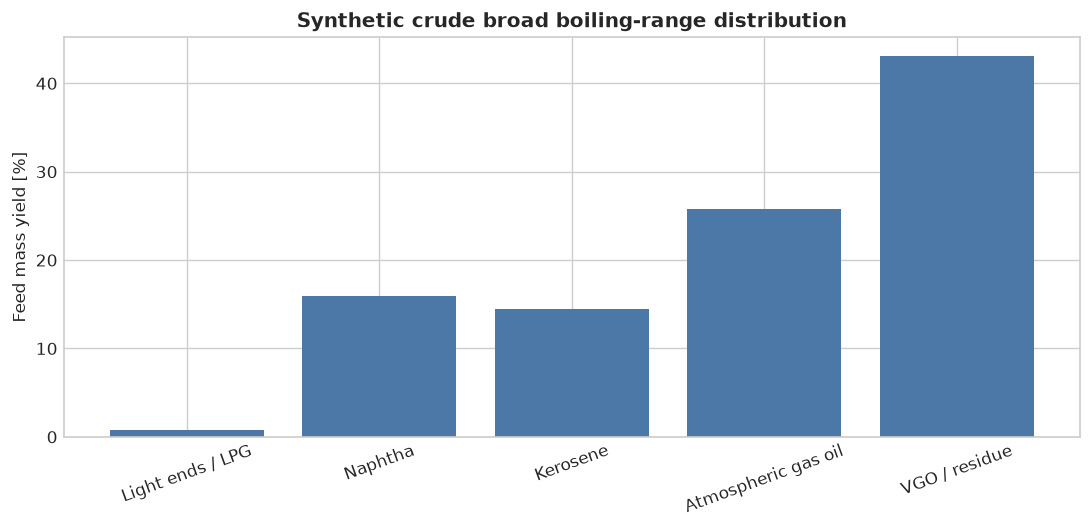

In [5]:
def cut_name(boiling_point_c):
    if boiling_point_c < 30.0:
        return "Light ends / LPG"
    if boiling_point_c < 180.0:
        return "Naphtha"
    if boiling_point_c < 270.0:
        return "Kerosene"
    if boiling_point_c < 370.0:
        return "Atmospheric gas oil"
    return "VGO / residue"


assay_records = []
for index in range(crude.getNumberOfComponents()):
    component = crude.getComponent(index)
    assay_records.append(
        {
            "Component": str(component.getComponentName()),
            "Mole fraction": component.getz(),
            "Molar mass [kg/mol]": component.getMolarMass(),
            "Normal boiling point [C]": (
                component.getNormalBoilingPoint() - 273.15
            ),
        }
    )
assay_table = pd.DataFrame(assay_records)
assay_table["Broad cut"] = assay_table["Normal boiling point [C]"].map(cut_name)
mass_basis = assay_table["Mole fraction"] * assay_table["Molar mass [kg/mol]"]
assay_table["Mass fraction"] = mass_basis / mass_basis.sum()
cut_order = [
    "Light ends / LPG",
    "Naphtha",
    "Kerosene",
    "Atmospheric gas oil",
    "VGO / residue",
]
feed_cut_yield = (
    assay_table.groupby("Broad cut")["Mass fraction"]
    .sum()
    .reindex(cut_order, fill_value=0.0)
)
display(assay_table.round(5))
display((100.0 * feed_cut_yield).rename("Feed mass yield [%]").to_frame().round(2))

figure, axis = plt.subplots(figsize=(9.2, 4.5))
axis.bar(cut_order, 100.0 * feed_cut_yield.to_numpy(), color="#4C78A8")
axis.set_ylabel("Feed mass yield [%]")
axis.set_title("Synthetic crude broad boiling-range distribution")
axis.tick_params(axis="x", rotation=20)
figure.tight_layout()
plt.show()

## 5. NeqSim refinery front-end flowsheet

The feed is heated and depressured into a preflash drum. Its liquid enters an atmospheric
furnace and a second equilibrium separator representing the flash zone. The model deliberately
does not label the flash-zone vapour as finished products: a real CDU needs trays, reflux,
pumparounds, steam, side draws, strippers, pressure profile, and calibrated efficiencies.

In [6]:
crude_feed = Stream("Synthetic crude feed", crude)
crude_feed.setFlowRate(100_000.0, "kg/hr")
crude_feed.setTemperature(25.0, "C")
crude_feed.setPressure(10.0, "bara")

preheater = Heater("Crude preheater", crude_feed)
preheater.setOutTemperature(180.0, "C")
preheater.setOutPressure(3.0, "bara")
preflash_drum = Separator("Preflash drum", preheater.getOutletStream())

atmospheric_furnace = Heater(
    "Atmospheric furnace", preflash_drum.getLiquidOutStream()
)
atmospheric_furnace.setOutTemperature(350.0, "C")
atmospheric_furnace.setOutPressure(2.0, "bara")
flash_zone = Separator(
    "Atmospheric flash-zone screen", atmospheric_furnace.getOutletStream()
)

refinery_process = ProcessSystem()
for unit in [
    crude_feed,
    preheater,
    preflash_drum,
    atmospheric_furnace,
    flash_zone,
]:
    refinery_process.add(unit)
refinery_process.run()

preheated_crude = preheater.getOutletStream()
preflash_vapour = preflash_drum.getGasOutStream()
preflash_liquid = preflash_drum.getLiquidOutStream()
furnace_outlet = atmospheric_furnace.getOutletStream()
flash_zone_vapour = flash_zone.getGasOutStream()
atmospheric_residue = flash_zone.getLiquidOutStream()
print("NeqSim refinery front-end calculation completed.")

NeqSim refinery front-end calculation completed.


In [7]:
def stream_state(stream):
    return {
        "Mass flow [kg/h]": stream.getFlowRate("kg/hr"),
        "Temperature [C]": stream.getTemperature("C"),
        "Pressure [bara]": stream.getPressure("bara"),
        "Phase count": stream.getFluid().getNumberOfPhases(),
    }


stream_table = pd.DataFrame.from_dict(
    {
        "Crude feed": stream_state(crude_feed),
        "Preheated crude": stream_state(preheated_crude),
        "Preflash vapour": stream_state(preflash_vapour),
        "Preflash liquid": stream_state(preflash_liquid),
        "Furnace outlet": stream_state(furnace_outlet),
        "Flash-zone vapour": stream_state(flash_zone_vapour),
        "Atmospheric residue": stream_state(atmospheric_residue),
    },
    orient="index",
)
display(stream_table.round(4))

,Mass flow [kg/h],Temperature [C],Pressure [bara],Phase count
Crude feed,100000.0000,25.0,10.0,1
Preheated crude,100000.0000,180.0,3.0,2
Preflash vapour,1776.4779,180.0,3.0,1
Preflash liquid,98223.5221,180.0,3.0,1
Furnace outlet,98223.5221,350.0,2.0,2
Flash-zone vapour,38966.6575,350.0,2.0,1
Atmospheric residue,59256.8646,350.0,2.0,1


## 6. Component and total-mass closure

Every inlet component must leave in preflash vapour, flash-zone vapour, or residue. The
calculation uses component molar rates from the converged streams and converts them to mass
with the same NeqSim molar masses.

In [8]:
component_names = assay_table["Component"].tolist()
component_molar_masses = assay_table["Molar mass [kg/mol]"].to_numpy()
component_cut_names = assay_table["Broad cut"].tolist()


def component_molar_rates(stream):
    total_rate = stream.getFlowRate("mole/sec")
    fluid = stream.getFluid()
    return np.asarray(
        [
            total_rate * fluid.getComponent(name).getz()
            for name in component_names
        ]
    )


def component_mass_rates_kg_h(stream):
    return component_molar_rates(stream) * component_molar_masses * 3600.0


feed_component_rates = component_molar_rates(crude_feed)
product_streams = {
    "Preflash vapour": preflash_vapour,
    "Flash-zone vapour": flash_zone_vapour,
    "Atmospheric residue": atmospheric_residue,
}
product_component_rates = {
    name: component_molar_rates(stream)
    for name, stream in product_streams.items()
}
component_residuals = (
    sum(product_component_rates.values()) - feed_component_rates
)
maximum_component_residual = float(np.max(np.abs(component_residuals)))
mass_residual_kg_h = (
    sum(stream.getFlowRate("kg/hr") for stream in product_streams.values())
    - crude_feed.getFlowRate("kg/hr")
)

balance_table = pd.DataFrame(
    {
        "Component": component_names,
        "Feed [mol/s]": feed_component_rates,
        **{
            f"{name} [mol/s]": rates
            for name, rates in product_component_rates.items()
        },
        "Residual [mol/s]": component_residuals,
    }
)
display(balance_table.round(8))
print(f"Mass residual: {mass_residual_kg_h:.3e} kg/h")
print(f"Maximum component residual: {maximum_component_residual:.3e} mol/s")

Mass residual: 2.321e-08 kg/h
Maximum component residual: 8.097e-12 mol/s


,Component,Feed [mol/s],Preflash vapour [mol/s],Flash-zone vapour [mol/s],Atmospheric residue [mol/s],Residual [mol/s]
0,methane,0.543262,4.761387e-01,0.066884,0.000240,-0.0
1,ethane,0.543262,4.045047e-01,0.137948,0.000810,-0.0
2,propane,1.086524,6.561500e-01,0.426779,0.003594,-0.0
3,n-butane,2.173048,9.674606e-01,1.191248,0.014339,-0.0
4,n-pentane,3.259571,9.974220e-01,2.225104,0.037045,-0.0
5,n-hexane,5.432619,1.079482e+00,4.256715,0.096422,-0.0
6,C7-C9_PC,13.038285,1.343389e+00,11.310115,0.384781,-0.0
7,C10-C12_PC,16.297856,4.637847e-01,14.822564,1.011508,-0.0
8,C13-C16_PC,19.557428,7.049139e-02,16.292046,3.194890,-0.0
9,C17-C24_PC,23.903523,2.493380e-03,10.758884,13.142146,0.0


## 7. Where each boiling-range cut goes

This recovery matrix is more useful than calling the vapour a finished distillate. Each
column distributes one feed boiling-range cut across the three equilibrium product streams.
A rigorous CDU model should replace these recoveries before product valuation.

,Preflash vapour,Flash-zone vapour,Atmospheric residue
Light ends / LPG,377.89,335.81,3.67
Naphtha,1343.86,13911.14,712.99
Kerosene,52.02,12023.53,2357.83
Atmospheric gas oil,2.69,11619.59,14193.52
VGO / residue,0.01,1076.58,41988.86


,Preflash vapour,Flash-zone vapour,Atmospheric residue
Light ends / LPG,52.68,46.81,0.51
Naphtha,8.42,87.12,4.47
Kerosene,0.36,83.30,16.34
Atmospheric gas oil,0.01,45.01,54.98
VGO / residue,0.00,2.50,97.50


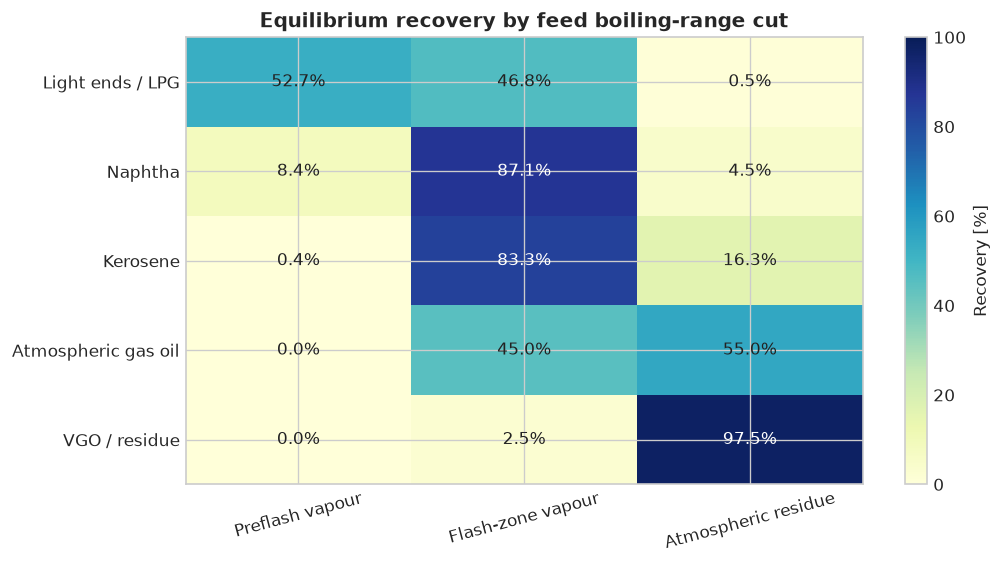

In [9]:
product_cut_mass = pd.DataFrame(
    0.0,
    index=cut_order,
    columns=list(product_streams),
)
for product_name, product_stream in product_streams.items():
    mass_rates = component_mass_rates_kg_h(product_stream)
    for broad_cut, mass_rate in zip(component_cut_names, mass_rates):
        product_cut_mass.loc[broad_cut, product_name] += mass_rate

cut_recovery = product_cut_mass.div(product_cut_mass.sum(axis=1), axis=0)
display(product_cut_mass.round(2))
display((100.0 * cut_recovery).round(2))

figure, axis = plt.subplots(figsize=(8.8, 4.8))
image_handle = axis.imshow(
    100.0 * cut_recovery.to_numpy(),
    aspect="auto",
    cmap="YlGnBu",
    vmin=0.0,
    vmax=100.0,
)
axis.set_xticks(range(len(product_streams)), labels=list(product_streams), rotation=15)
axis.set_yticks(range(len(cut_order)), labels=cut_order)
axis.set_title("Equilibrium recovery by feed boiling-range cut")
for row in range(len(cut_order)):
    for column in range(len(product_streams)):
        value = 100.0 * cut_recovery.iloc[row, column]
        text_colour = "white" if value >= 60.0 else "#222222"
        axis.text(
            column,
            row,
            f"{value:.1f}%",
            ha="center",
            va="center",
            color=text_colour,
        )
figure.colorbar(image_handle, ax=axis, label="Recovery [%]")
figure.tight_layout()
plt.show()

## 8. Heater duties, heat recovery, fuel, and direct emissions

NeqSim heater duties close against stream enthalpy changes. A simple heat-recovery factor
then converts gross duty to purchased heat. Fuel and direct CO2 use explicit assumptions;
they are not lifecycle emissions and exclude electricity, hydrogen, steam, flaring, and
upstream supply.

,Unit,Reported duty [MW],Enthalpy change [MW],Residual [W]
0,Crude preheater,9.456718,9.456718,0.0
1,Atmospheric furnace,14.931989,14.931989,0.0


,Heat recovered [% of preheater duty],Purchased heat [MW],Heat intensity [kWh/t feed],Fuel [kg/h],Direct CO2 [t/h]
0,0.0,24.389,243.887,1995.440,5.597
1,40.0,20.606,206.060,1685.947,4.729
2,60.0,18.715,187.147,1531.201,4.295
3,75.0,17.296,172.962,1415.141,3.969


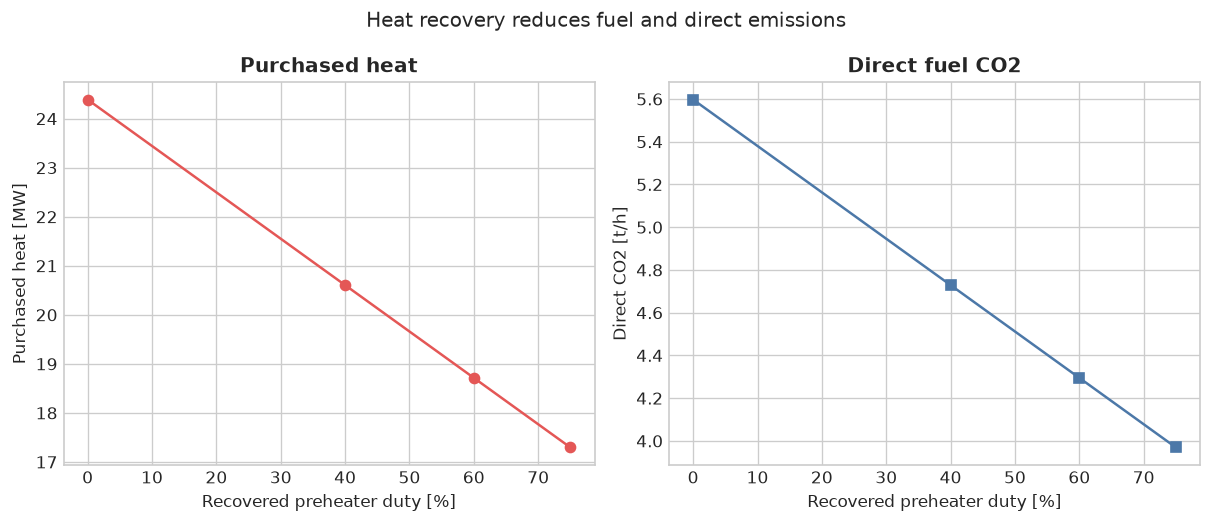

In [10]:
preheater_duty_w = preheater.getDuty()
furnace_duty_w = atmospheric_furnace.getDuty()
preheater_delta_h_w = (
    preheated_crude.getFluid().getEnthalpy("J")
    - crude_feed.getFluid().getEnthalpy("J")
)
furnace_delta_h_w = (
    furnace_outlet.getFluid().getEnthalpy("J")
    - preflash_liquid.getFluid().getEnthalpy("J")
)
preheater_energy_residual_w = preheater_duty_w - preheater_delta_h_w
furnace_energy_residual_w = furnace_duty_w - furnace_delta_h_w
energy_balance = pd.DataFrame(
    {
        "Unit": ["Crude preheater", "Atmospheric furnace"],
        "Reported duty [MW]": [preheater_duty_w / 1.0e6, furnace_duty_w / 1.0e6],
        "Enthalpy change [MW]": [preheater_delta_h_w / 1.0e6, furnace_delta_h_w / 1.0e6],
        "Residual [W]": [preheater_energy_residual_w, furnace_energy_residual_w],
    }
)
display(energy_balance.round(6))

heat_recovery_fraction = np.asarray([0.0, 0.40, 0.60, 0.75])
feed_rate_t_h = crude_feed.getFlowRate("kg/hr") / 1000.0
FURNACE_EFFICIENCY = 0.88
FUEL_LHV_MJ_KG = 50.0
FUEL_EMISSION_KG_CO2_GJ = 56.1
purchased_heat_mw = (
    furnace_duty_w + (1.0 - heat_recovery_fraction) * preheater_duty_w
) / 1.0e6
fuel_gj_h = purchased_heat_mw * 3.6 / FURNACE_EFFICIENCY
fuel_kg_h = fuel_gj_h * 1000.0 / FUEL_LHV_MJ_KG
direct_co2_t_h = fuel_gj_h * FUEL_EMISSION_KG_CO2_GJ / 1000.0
utility_scenarios = pd.DataFrame(
    {
        "Heat recovered [% of preheater duty]": 100.0 * heat_recovery_fraction,
        "Purchased heat [MW]": purchased_heat_mw,
        "Heat intensity [kWh/t feed]": purchased_heat_mw * 1000.0 / feed_rate_t_h,
        "Fuel [kg/h]": fuel_kg_h,
        "Direct CO2 [t/h]": direct_co2_t_h,
    }
)
display(utility_scenarios.round(3))

figure, axes = plt.subplots(1, 2, figsize=(10.2, 4.4))
axes[0].plot(
    100.0 * heat_recovery_fraction,
    purchased_heat_mw,
    marker="o",
    color="#E45756",
)
axes[0].set_xlabel("Recovered preheater duty [%]")
axes[0].set_ylabel("Purchased heat [MW]")
axes[0].set_title("Purchased heat")
axes[1].plot(
    100.0 * heat_recovery_fraction,
    direct_co2_t_h,
    marker="s",
    color="#4C78A8",
)
axes[1].set_xlabel("Recovered preheater duty [%]")
axes[1].set_ylabel("Direct CO2 [t/h]")
axes[1].set_title("Direct fuel CO2")
figure.suptitle("Heat recovery reduces fuel and direct emissions")
figure.tight_layout()
plt.show()

## 9. Atmospheric flash-temperature sensitivity

Temperature changes equilibrium vapourisation and furnace duty. A real operating decision
must also respect heater tube-metal temperature, coking, column hydraulics, product quality,
energy integration, and downstream constraints.

,Flash temperature [C],Vapour mole fraction,Incremental duty [kWh/t feed]
0,300.0,0.43713,101.75229
1,320.0,0.50518,120.39250
2,340.0,0.57420,139.57658
3,350.0,0.60846,149.31989
4,360.0,0.64161,159.10113
5,380.0,0.70223,178.62664


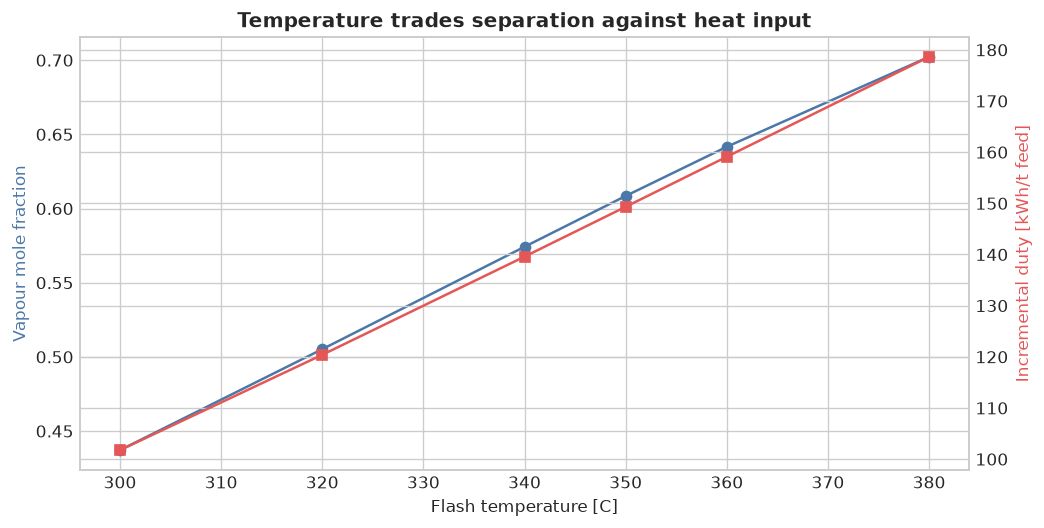

In [11]:
temperature_cases_c = np.asarray([300.0, 320.0, 340.0, 350.0, 360.0, 380.0])
temperature_vapour_fraction = []
temperature_specific_duty_kwh_t = []
for temperature_c in temperature_cases_c:
    heater_case = Heater(
        f"Atmospheric furnace at {temperature_c:.0f} C",
        preflash_liquid,
    )
    heater_case.setOutTemperature(float(temperature_c), "C")
    heater_case.setOutPressure(2.0, "bara")
    heater_case.run()
    flash_case = heater_case.getOutletStream().getFluid()
    temperature_vapour_fraction.append(flash_case.getPhase("gas").getBeta())
    temperature_specific_duty_kwh_t.append(
        heater_case.getDuty() / 1000.0 / feed_rate_t_h
    )

temperature_sensitivity = pd.DataFrame(
    {
        "Flash temperature [C]": temperature_cases_c,
        "Vapour mole fraction": temperature_vapour_fraction,
        "Incremental duty [kWh/t feed]": temperature_specific_duty_kwh_t,
    }
)
display(temperature_sensitivity.round(5))

figure, axis_left = plt.subplots(figsize=(8.8, 4.5))
axis_left.plot(
    temperature_cases_c,
    temperature_vapour_fraction,
    marker="o",
    color="#4C78A8",
)
axis_left.set_xlabel("Flash temperature [C]")
axis_left.set_ylabel("Vapour mole fraction", color="#4C78A8")
axis_right = axis_left.twinx()
axis_right.plot(
    temperature_cases_c,
    temperature_specific_duty_kwh_t,
    marker="s",
    color="#E45756",
)
axis_right.set_ylabel("Incremental duty [kWh/t feed]", color="#E45756")
axis_left.set_title("Temperature trades separation against heat input")
figure.tight_layout()
plt.show()

## 10. Refinery value and a constrained crude-slate screen

The front-end cut distribution connects to product values, but equilibrium cut mass is not
a finished-product yield. The first calculation is a gross-product-worth screen. The LP then
chooses between two synthetic planning vectors under CDU throughput and residue-handling
limits. A production LP would include every unit, quality pool, inventory, energy, and
contract constraint.

In [12]:
product_value_usd_bbl_feed = pd.Series(
    {
        "Light ends / LPG": 72.0,
        "Naphtha": 84.0,
        "Kerosene": 101.0,
        "Atmospheric gas oil": 96.0,
        "VGO / residue": 61.0,
    }
)
gross_product_worth_usd_bbl = float(
    (feed_cut_yield * product_value_usd_bbl_feed).sum()
)
CRUDE_DELIVERED_USD_BBL = 80.0
VARIABLE_COST_USD_BBL = 5.5
screening_margin_usd_bbl = (
    gross_product_worth_usd_bbl
    - CRUDE_DELIVERED_USD_BBL
    - VARIABLE_COST_USD_BBL
)
value_summary = pd.Series(
    {
        "Gross product worth [USD/bbl feed]": gross_product_worth_usd_bbl,
        "Delivered crude [USD/bbl]": CRUDE_DELIVERED_USD_BBL,
        "Variable refining cost [USD/bbl]": VARIABLE_COST_USD_BBL,
        "Screening margin [USD/bbl]": screening_margin_usd_bbl,
    }
)
display(value_summary.to_frame("Synthetic base case").round(3))

planning_crudes = pd.DataFrame(
    {
        "Margin [USD/bbl]": [screening_margin_usd_bbl, screening_margin_usd_bbl + 1.8],
        "Residue yield": [float(feed_cut_yield["VGO / residue"]), 0.22],
        "Hydrogen index": [0.70, 1.05],
    },
    index=["Base North Sea", "Light sweet alternative"],
)
capacity_kbbl_day = 100.0
lp_result = linprog(
    c=-planning_crudes["Margin [USD/bbl]"].to_numpy(),
    A_ub=np.asarray(
        [
            planning_crudes["Residue yield"].to_numpy(),
            planning_crudes["Hydrogen index"].to_numpy(),
        ]
    ),
    b_ub=np.asarray([36.0, 88.0]),
    bounds=[(0.0, capacity_kbbl_day), (0.0, capacity_kbbl_day)],
    A_eq=np.asarray([[1.0, 1.0]]),
    b_eq=np.asarray([capacity_kbbl_day]),
    method="highs",
)
assert lp_result.success, lp_result.message
planning_result = planning_crudes.copy()
planning_result["Run [kbbl/day]"] = lp_result.x
planning_result["Margin [kUSD/day]"] = (
    planning_result["Run [kbbl/day]"] * planning_result["Margin [USD/bbl]"]
)
display(planning_result.round(3))
print(f"Optimised variable margin: {-lp_result.fun:.2f} kUSD/day")
if -lp_result.fun < 0.0:
    print(
        "All feasible synthetic crude choices have negative variable margin; "
        "the LP selects the least-negative permitted slate."
    )

Optimised variable margin: -501.39 kUSD/day
All feasible synthetic crude choices have negative variable margin; the LP selects the least-negative permitted slate.


,Synthetic base case
Gross product worth [USD/bbl feed],79.56
Delivered crude [USD/bbl],80.00
Variable refining cost [USD/bbl],5.50
Screening margin [USD/bbl],-5.94


,Margin [USD/bbl],Residue yield,Hydrogen index,Run [kbbl/day],Margin [kUSD/day]
Base North Sea,-5.94,0.431,0.70,48.571,-288.493
Light sweet alternative,-4.14,0.220,1.05,51.429,-212.892


## 11. Validation and model limitations

Named checks make failures visible when the notebook, Java source, or assumptions change.
Tolerance checks are deliberately tighter than plot-level inspection.

In [13]:
grouped_product_mass_kg_h = float(product_cut_mass.to_numpy().sum())
product_mass_kg_h = sum(
    stream.getFlowRate("kg/hr") for stream in product_streams.values()
)
checks = {
    "NeqSim refinery class loaded from source JAR": str(NEQSIM_JAR) in refinery_class_source,
    "Synthetic assay closes": math.isclose(assay_sum, 1.0, abs_tol=1.0e-12),
    "Feed cut yields close": math.isclose(feed_cut_yield.sum(), 1.0, abs_tol=1.0e-12),
    "All three product streams are positive": all(
        stream.getFlowRate("kg/hr") > 0.0 for stream in product_streams.values()
    ),
    "Overall mass balance closes": abs(mass_residual_kg_h) < 1.0e-5,
    "Component balances close": maximum_component_residual < 1.0e-8,
    "Grouped cut mass matches streams": abs(grouped_product_mass_kg_h - product_mass_kg_h) < 1.0e-4,
    "Every cut recovery closes": np.allclose(cut_recovery.sum(axis=1), 1.0, atol=1.0e-10),
    "Preheater energy closes": abs(preheater_energy_residual_w) < 1.0e-5,
    "Furnace energy closes": abs(furnace_energy_residual_w) < 1.0e-5,
    "Both heater duties are positive": preheater_duty_w > 0.0 and furnace_duty_w > 0.0,
    "Heat recovery lowers purchased heat": np.all(np.diff(purchased_heat_mw) < 0.0),
    "Heat recovery lowers direct CO2": np.all(np.diff(direct_co2_t_h) < 0.0),
    "Temperature raises vapour fraction": np.all(np.diff(temperature_vapour_fraction) > 0.0),
    "Temperature raises duty": np.all(np.diff(temperature_specific_duty_kwh_t) > 0.0),
    "Planning LP solved": lp_result.success,
    "Screening margin finite": math.isfinite(screening_margin_usd_bbl),
}
validation_table = pd.DataFrame({"Check": list(checks), "Passed": list(checks.values())})
display(validation_table)
assert all(checks.values()), [name for name, passed in checks.items() if not passed]
print(f"All {len(checks)} named checks passed.")

All 17 named checks passed.


,Check,Passed
0,NeqSim refinery class loaded from source JAR,True
1,Synthetic assay closes,True
2,Feed cut yields close,True
3,All three product streams are positive,True
4,Overall mass balance closes,True
5,Component balances close,True
6,Grouped cut mass matches streams,True
7,Every cut recovery closes,True
8,Preheater energy closes,True
9,Furnace energy closes,True


### What NeqSim does and does not establish

NeqSim is well suited here for pseudo-component characterization, phase equilibrium,
thermophysical properties, stream states, front-end flashes, heater duties, and composable
process models. Before operational use, calibrate against a real assay and plant data and
add rigorous fractionation, hydraulics, heat-exchanger networks, product specifications,
and uncertainty.

Hydrotreating, reforming, FCC, hydrocracking, coking, sulfur recovery, catalyst ageing,
fouling, and detailed refinery blending require reaction, separation, and planning models
beyond this notebook. Never treat an equilibrium flash as a licensed refinery yield model.

## 12. Connections to the NeqSim notebook library

- Start with [European crude-oil sales](../gasvaluechain/european_crude_oil_sales_foundation.ipynb)
  for cargo price, quality, quantity, logistics, buyer value, and producer netback.
- Compare the established [crude-oil preflash and atmospheric flash-zone screen](oilrefineries.ipynb)
  for an independent implementation and EOS sensitivity.
- Use [multistage oil stabilisation](Simulationofanoilstabilizationprocess.ipynb) for upstream
  export-crude volatility and recovery.
- Connect to [oil and gas production optimisation](../production/oilgasproductionoptimization.ipynb)
  for upstream availability and facility constraints.
- Add emissions methods from the repository's sustainability and process notebooks before
  making lifecycle claims.

In [14]:
provenance = pd.DataFrame(
    {
        "Component": [
            "NeqSim Java commit",
            "NeqSim JAR SHA-256",
            "Python",
            "NumPy",
            "pandas",
            "SciPy",
            "Assay, prices, and operating data",
        ],
        "Identity": [
            NEQSIM_COMMIT,
            NEQSIM_JAR_SHA256,
            platform.python_version(),
            np.__version__,
            pd.__version__,
            scipy.__version__,
            "synthetic teaching snapshot dated 2026-08-05",
        ],
    }
)
display(provenance)

,Component,Identity
0,NeqSim Java commit,7ae08253b45180045a99a700314f23c9a7001b3c
1,NeqSim JAR SHA-256,d1bdf734644537f2304d17e2e354008c48f189858a9055...
2,Python,3.12.13
3,NumPy,2.5.1
4,pandas,3.0.5
5,SciPy,1.18.0
6,"Assay, prices, and operating data",synthetic teaching snapshot dated 2026-08-05


## References

- NeqSim source, process equipment, thermodynamics, and standards documentation.
- API Technical Data Book: petroleum fraction characterization and distillation methods.
- ASTM petroleum measurement and product-test methods used by the governing laboratory
  and commercial procedures.
- European crude-oil sales foundation notebook in this repository for market interfaces.

All numerical prices, assay values, operating conditions, heat-recovery factors, fuel
properties, emission factors, and constraints in this notebook are illustrative.